# Lab 4: Motors and Open Loop Control

This notebook covers all data-collection and analysis tasks for Lab 4:
1. Connect to Artemis via BLE
2. Basic motor control (forward / backward / stop / turns)
3. **Task 8** — Lower PWM limit (forward + on-axis turns)
4. **Task 9** — Calibration for straight-line driving
5. **Task 10** — Open loop untethered control with turns
6. **(5000) Task 11** — `analogWrite` frequency discussion
7. **(5000) Task 12** — Minimum PWM to sustain motion once rolling

## 1. Setup and Imports

In [5]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import importlib

from ble import get_ble_controller
from base_ble import LOG
import cmd_types
importlib.reload(cmd_types)
from cmd_types import CMD

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['font.size'] = 12

## 2. Connect to Artemis via BLE

In [6]:
ble = get_ble_controller()
ble.connect()
print("Connected!")

2026-03-11 02:32:20,401 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:81:31:25:23:64
2026-03-11 02:32:20,401 | INFO     |: Scanning for device with address: c0:81:31:25:23:64, service UUID: d1e59283-ea64-46d2-9619-feda9179e362
2026-03-11 02:32:30,468 | INFO     |: Found 1 device(s) advertising service d1e59283-ea64-46d2-9619-feda9179e362
2026-03-11 02:32:30,469 | INFO     |: Selecting device: CA4CC09F-B046-D9C9-C03F-F04C7AD18338 (name: Artemis BLE)
2026-03-11 02:32:52,273 | INFO     |: Connected to c0:81:31:25:23:64
Connected!


In [7]:
# Verify connection
ble.send_command(CMD.PING, "")
response = ble.receive_string(ble.uuid['RX_STRING'])
print(f"Response: {response}")

Response: PONG


## 3. Motor Helper Functions

In [8]:
def motor_forward(speed, duration_ms=0):
    """Drive forward. duration_ms=0 → run until motor_stop()."""
    ble.send_command(CMD.MOTOR_FORWARD, f"{speed}:{duration_ms}")
    time.sleep(0.1)
    return ble.receive_string(ble.uuid['RX_STRING'])

def motor_backward(speed, duration_ms=0):
    ble.send_command(CMD.MOTOR_BACKWARD, f"{speed}:{duration_ms}")
    time.sleep(0.1)
    return ble.receive_string(ble.uuid['RX_STRING'])

def motor_stop():
    ble.send_command(CMD.MOTOR_STOP, "")
    time.sleep(0.1)
    return ble.receive_string(ble.uuid['RX_STRING'])

def motor_turn_left(speed, duration_ms=0):
    ble.send_command(CMD.MOTOR_TURN_LEFT, f"{speed}:{duration_ms}")
    time.sleep(0.1)
    return ble.receive_string(ble.uuid['RX_STRING'])

def motor_turn_right(speed, duration_ms=0):
    ble.send_command(CMD.MOTOR_TURN_RIGHT, f"{speed}:{duration_ms}")
    time.sleep(0.1)
    return ble.receive_string(ble.uuid['RX_STRING'])

def set_motor_cal(cal_factor):
    """Set right-motor calibration factor (>1 → right faster, <1 → right slower)."""
    ble.send_command(CMD.SET_MOTOR_CAL, str(cal_factor))
    time.sleep(0.1)
    return ble.receive_string(ble.uuid['RX_STRING'])

def motor_turn_angle(direction, angle_deg=90, timeout_s=8.0):
    """
    Gyro-controlled turn at PWM 140 until angle_deg is reached.
    Polls receive_string every 100 ms until Artemis sends TURN_DONE or timeout.
    Returns the TURN_DONE message or 'TIMEOUT'.
    """
    dir_code = 0 if direction == 'left' else 1
    ble.send_command(CMD.MOTOR_TURN_ANGLE, f"{dir_code}:{angle_deg}")
    time.sleep(0.15)
    ack = ble.receive_string(ble.uuid['RX_STRING'])
    print(f"  ack: {ack}")

    t0 = time.time()
    while time.time() - t0 < timeout_s:
        time.sleep(0.1)
        try:
            msg = ble.receive_string(ble.uuid['RX_STRING'])
            if 'TURN_DONE' in msg:
                print(f"  result: {msg}")
                return msg
        except Exception:
            pass

    motor_stop()
    print("  result: TIMEOUT")
    return 'TIMEOUT'

print("Motor helper functions defined.")

Motor helper functions defined.


In [9]:
# ── IMU-Based Motion Detection ────────────────────────────────────────────────
# IMU axes (as mounted in car):
#   forward = +X  |  left = +Y  |  right = -Y  |  up = +Z
#
# Detection criteria:
#   Forward moved  →  integrated displacement > FWD_MIN_DIST_CM
#   Turn moved     →  |integrated rotation|   > TURN_MIN_DEG
#
# Artemis firmware must extend SEND_IMU_DATA to output 7 fields per line:
#   "T|pa|ra|pc|rc|ax|gz"
#   ax  = ICM accel X  in g      (forward axis)
#   gz  = ICM gyro  Z  in deg/s  (yaw / on-axis-turn axis)
#
# Minimal C++ change in the SEND_IMU_DATA handler (after existing 5 fields):
#   tx_estring_value.append('|');
#   tx_estring_value.append(accel_x_buf[i]);   // pre-scaled to g
#   tx_estring_value.append('|');
#   tx_estring_value.append(gyro_z_buf[i]);    // pre-scaled to deg/s

FWD_MIN_DIST_CM  = 3.0   # cm   — min displacement to count as 'moved'
TURN_MIN_DEG     = 5.0   # deg  — min rotation    to count as 'turned'
IMU_SAMPLE_RATE  = 100   # Hz   — Artemis recording rate

_imu_buf = []

def _imu_handler(sender, data):
    global _imu_buf
    try:
        _imu_buf.append(data.decode('utf-8'))
    except Exception:
        pass


def _collect_imu_during_motor(motor_fn, pwm, duration_ms, extra_wait_s=0.5):
    """
    Start IMU recording, run motor for duration_ms, collect IMU data.
    Returns raw string buffer.
    """
    global _imu_buf
    _imu_buf = []

    ble.start_notify(ble.uuid['RX_STRING'], _imu_handler)
    time.sleep(0.05)

    ble.send_command(CMD.START_IMU_RECORDING, "")
    time.sleep(0.05)

    motor_fn(pwm, duration_ms)          # Artemis handles motor timing

    time.sleep(duration_ms / 1000.0 + extra_wait_s)  # wait for motor + settle

    ble.send_command(CMD.STOP_IMU_RECORDING, "")
    time.sleep(0.1)

    ble.send_command(CMD.SEND_IMU_DATA, "")
    est_samples = (duration_ms / 1000.0 + extra_wait_s) * IMU_SAMPLE_RATE
    time.sleep(est_samples * 0.04 + 2.0)  # ~35 ms per BLE packet + buffer

    ble.stop_notify(ble.uuid['RX_STRING'])
    return list(_imu_buf)


def _parse_imu_extended(buf):
    """
    Parse IMU buffer into DataFrame.
    7-field format: T|pa|ra|pc|rc|ax|gz   (ax in g, gz in deg/s)
    Falls back to 5-field format (ax/gz = NaN) if firmware not yet updated.
    """
    rows = []
    for line in buf:
        parts = line.strip().split('|')
        try:
            if len(parts) == 7:
                t, pa, ra, pc, rc, ax, gz = [float(x) for x in parts]
            elif len(parts) == 5:
                t, pa, ra, pc, rc = [float(x) for x in parts]
                ax = gz = np.nan
            else:
                continue
            rows.append({'time_ms': t, 'pitch_a': pa, 'roll_a': ra,
                         'pitch_comp': pc, 'roll_comp': rc,
                         'accel_x_g': ax, 'gyro_z_dps': gz})
        except ValueError:
            pass
    df = pd.DataFrame(rows)
    if len(df) > 0:
        df['time_s'] = (df['time_ms'] - df['time_ms'].iloc[0]) / 1000.0
    return df


def _detect_forward_motion(df):
    """
    Return (moved: bool, displacement_cm: float).
    Primary method : integrate accel_x (g → m/s²) twice → displacement.
    Fallback method: std of pitch_comp as vibration proxy (less reliable).
    """
    if df.empty:
        return False, 0.0

    if not df['accel_x_g'].isna().all():
        # Bias: mean over first 80 ms (car still, motors just starting)
        mask = df['time_s'] < 0.08
        bias = df.loc[mask, 'accel_x_g'].mean() if mask.any() else df['accel_x_g'].mean()
        ax = (df['accel_x_g'].values - bias) * 9.81   # m/s²
        t  = df['time_s'].values
        dt = np.diff(t)
        # Trapezoidal velocity integration
        vel = np.zeros(len(t))
        for i in range(1, len(t)):
            vel[i] = vel[i-1] + (ax[i-1] + ax[i]) / 2 * dt[i-1]
        # Trapezoidal position integration
        pos = np.zeros(len(t))
        for i in range(1, len(t)):
            pos[i] = pos[i-1] + (vel[i-1] + vel[i]) / 2 * dt[i-1]
        disp_cm = float(np.max(np.abs(pos)) * 100)
        return disp_cm > FWD_MIN_DIST_CM, disp_cm
    else:
        # Fallback: vibration in pitch_comp while motor runs
        std = float(df['pitch_comp'].std())
        return std > 1.5, std   # metric is std-degrees, not cm


def _detect_turn_motion(df):
    """
    Return (moved: bool, total_angle_deg: float).
    Primary method : integrate gyro_z (deg/s) → total rotation angle.
    Fallback method: std of roll_comp as vibration proxy (less reliable).
    """
    if df.empty:
        return False, 0.0

    if not df['gyro_z_dps'].isna().all():
        # Bias: mean over first 80 ms
        mask = df['time_s'] < 0.08
        bias = df.loc[mask, 'gyro_z_dps'].mean() if mask.any() else df['gyro_z_dps'].mean()
        gz = df['gyro_z_dps'].values - bias
        t  = df['time_s'].values
        total_angle = float(np.trapz(gz, t))
        return abs(total_angle) > TURN_MIN_DEG, total_angle
    else:
        # Fallback: vibration in roll_comp
        std = float(df['roll_comp'].std())
        return std > 1.5, std


print('IMU motion-detection helpers defined.')
print(f'  Forward threshold : {FWD_MIN_DIST_CM} cm displacement')
print(f'  Turn threshold    : {TURN_MIN_DEG} deg rotation')


IMU motion-detection helpers defined.
  Forward threshold : 3.0 cm displacement
  Turn threshold    : 5.0 deg rotation


## 4. Basic Motor Test

Verify all four directions work. Place car on its side (wheels elevated) for safety.

In [10]:
# ── Forward 1 s ──────────────────────────────────────────────────────────────
print(motor_forward(150, 1000))
time.sleep(1.5)

MOTOR_FWD|150


In [11]:
# ── Backward 1 s ─────────────────────────────────────────────────────────────
print(motor_backward(150, 1000))
time.sleep(1.5)

MOTOR_BWD|150


In [12]:
# ── Left turn 0.5 s then right turn 0.5 s ────────────────────────────────────
print(motor_turn_left(150, 500))
time.sleep(0.8)
print(motor_turn_right(150, 500))
time.sleep(0.8)
print(motor_stop())

MOTOR_LEFT|150
MOTOR_RIGHT|150
MOTOR_STOP


---
## 5. Task 8 — Lower PWM Limit

Find the minimum PWM value at which the robot:
- (a) starts moving **forward** from rest
- (b) performs an **on-axis turn** from rest

**Protocol**: start from a higher PWM and step down until the robot stops moving.  
Record `(pwm, moved: bool)` for each trial.

In [13]:
# ── Forward lower-limit sweep (IMU-based) ─────────────────────────────────────
# Detect forward motion by integrating accel_x twice → displacement.
# Coarse sweep 100→15 (step 5), then fine sweep ±5 around first stall.
# Extended range vs. old version (which bottomed out at 40 without finding limit).

MOTOR_DURATION_MS = 1000   # ms per trial (longer = more integration time)
fwd_pwm_results   = []

first_stall_pwm = None
for pwm in range(100, 14, -5):
    print(f'Testing forward PWM={pwm:3d} ... ', end='', flush=True)
    buf  = _collect_imu_during_motor(motor_forward, pwm, MOTOR_DURATION_MS)
    df   = _parse_imu_extended(buf)
    moved, metric = _detect_forward_motion(df)
    fwd_pwm_results.append({'pwm': pwm, 'moved': moved,
                             'metric_cm': metric, 'n_samples': len(df)})
    label = f'MOVED  ({metric:.1f} cm)' if moved else f'STALLED({metric:.1f} cm)'
    print(f'{label}  [n={len(df)}]')
    time.sleep(0.5)

    if not moved and first_stall_pwm is None:
        first_stall_pwm = pwm
        print(f'  → First stall at PWM={pwm}. Running fine sweep ...')
        break
else:
    print('\n  ⚠ Robot moved at all tested PWMs — extend range below 15.')

# Fine sweep: ±5 around threshold
if first_stall_pwm is not None:
    lo = max(first_stall_pwm - 4, 5)
    hi = first_stall_pwm + 5
    already_tested = {r['pwm'] for r in fwd_pwm_results}
    for fine_pwm in range(hi, lo - 1, -1):
        if fine_pwm in already_tested:
            continue
        print(f'  Fine PWM={fine_pwm:3d} ... ', end='', flush=True)
        buf  = _collect_imu_during_motor(motor_forward, fine_pwm, MOTOR_DURATION_MS)
        df   = _parse_imu_extended(buf)
        moved, metric = _detect_forward_motion(df)
        fwd_pwm_results.append({'pwm': fine_pwm, 'moved': moved,
                                 'metric_cm': metric, 'n_samples': len(df)})
        label = f'MOVED  ({metric:.1f} cm)' if moved else f'STALLED({metric:.1f} cm)'
        print(label)
        time.sleep(0.5)

df_fwd_limit = pd.DataFrame(fwd_pwm_results).sort_values('pwm').reset_index(drop=True)
print('\nForward PWM limit results:')
print(df_fwd_limit)


Testing forward PWM=100 ... MOVED  (7.4 cm)  [n=102]
Testing forward PWM= 95 ... 

KeyboardInterrupt: 

In [ ]:
# ── On-axis turn lower-limit sweep (IMU-based) ────────────────────────────────
# Detect rotation by integrating gyro_z → total angle turned.
# Previous result showed threshold near 130 PWM — start from 150 step 5.

turn_pwm_results  = []
first_stall_pwm_t = None

for pwm in range(150, 99, -5):
    print(f'Testing turn PWM={pwm:3d} ... ', end='', flush=True)
    buf  = _collect_imu_during_motor(motor_turn_right, pwm, MOTOR_DURATION_MS)
    df   = _parse_imu_extended(buf)
    moved, metric = _detect_turn_motion(df)
    turn_pwm_results.append({'pwm': pwm, 'moved': moved,
                              'angle_deg': metric, 'n_samples': len(df)})
    label = f'TURNED ({metric:.1f}°)' if moved else f'STALLED({metric:.1f}°)'
    print(f'{label}  [n={len(df)}]')
    time.sleep(0.5)

    if not moved and first_stall_pwm_t is None:
        first_stall_pwm_t = pwm
        print(f'  → First stall at PWM={pwm}. Running fine sweep ...')
        break
else:
    print('\n  ⚠ Robot turned at all tested PWMs — extend range below 100.')

# Fine sweep
if first_stall_pwm_t is not None:
    lo = max(first_stall_pwm_t - 4, 90)
    hi = first_stall_pwm_t + 5
    already_tested_t = {r['pwm'] for r in turn_pwm_results}
    for fine_pwm in range(hi, lo - 1, -1):
        if fine_pwm in already_tested_t:
            continue
        print(f'  Fine PWM={fine_pwm:3d} ... ', end='', flush=True)
        buf  = _collect_imu_during_motor(motor_turn_right, fine_pwm, MOTOR_DURATION_MS)
        df   = _parse_imu_extended(buf)
        moved, metric = _detect_turn_motion(df)
        turn_pwm_results.append({'pwm': fine_pwm, 'moved': moved,
                                  'angle_deg': metric, 'n_samples': len(df)})
        label = f'TURNED ({metric:.1f}°)' if moved else f'STALLED({metric:.1f}°)'
        print(label)
        time.sleep(0.5)

df_turn_limit = pd.DataFrame(turn_pwm_results).sort_values('pwm').reset_index(drop=True)
print('\nTurn PWM limit results:')
print(df_turn_limit)


Testing turn PWM=150 ... TURNED (1.5°)  [n=100]
Testing turn PWM=145 ... TURNED (3.3°)  [n=106]
Testing turn PWM=140 ... TURNED (4.6°)  [n=98]
Testing turn PWM=135 ... STALLED(1.5°)  [n=104]
  → First stall at PWM=135. Running fine sweep ...
  Fine PWM=139 ... TURNED (1.6°)
  Fine PWM=138 ... STALLED(1.1°)
  Fine PWM=137 ... TURNED (2.7°)
  Fine PWM=136 ... TURNED (1.6°)
  Fine PWM=134 ... STALLED(1.1°)
  Fine PWM=133 ... TURNED (1.7°)
  Fine PWM=132 ... STALLED(0.6°)
  Fine PWM=131 ... STALLED(1.0°)

Turn PWM limit results:
    pwm  moved  angle_deg  n_samples
0   131  False   1.042455         88
1   132  False   0.608796         93
2   133   True   1.719486         92
3   134  False   1.087071         94
4   135  False   1.478284        104
5   136   True   1.618048         99
6   137   True   2.650045        104
7   138  False   1.093705        105
8   139   True   1.580496        102
9   140   True   4.609289         98
10  145   True   3.281857        106
11  150   True   1.516615

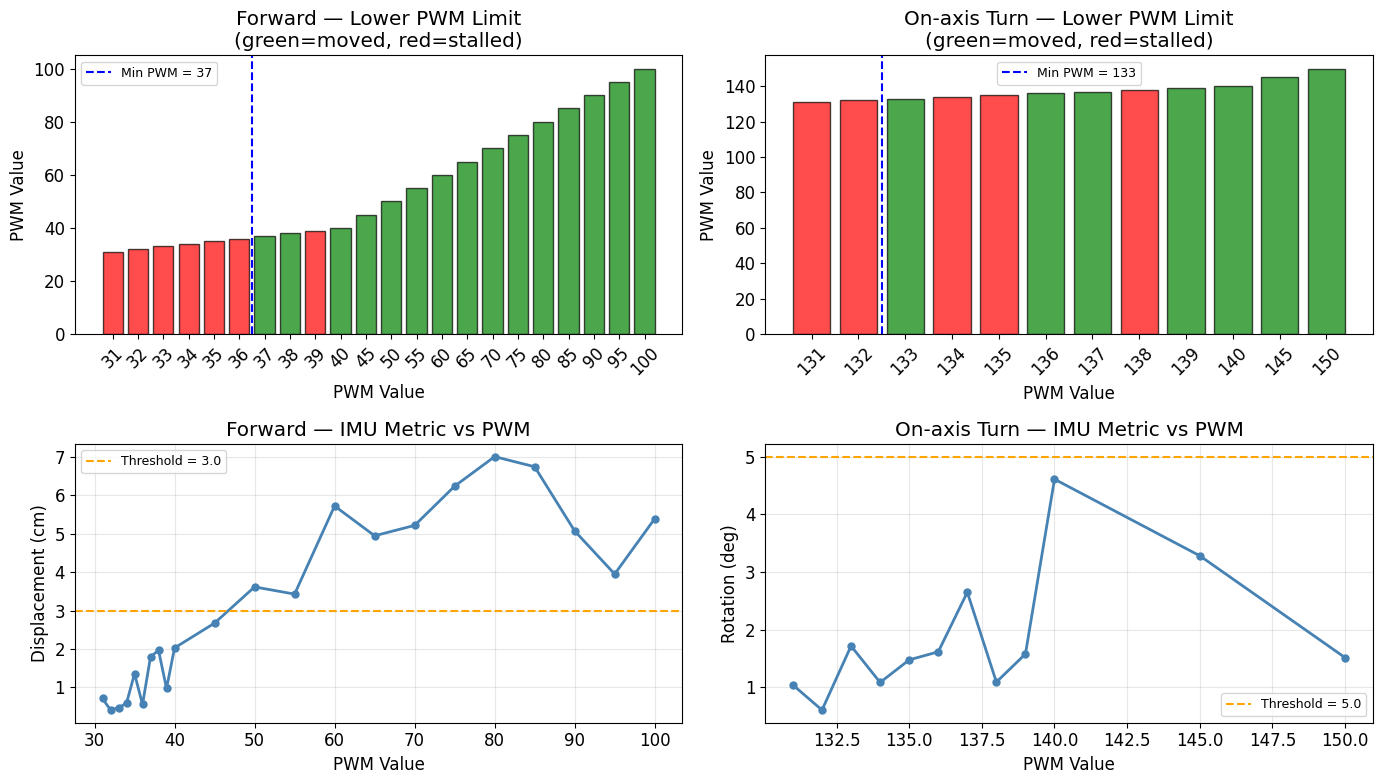

Forward minimum PWM : 37
Turn    minimum PWM : 133


In [ ]:
# ── Summary plot (binary + metric overlay) ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

datasets = [
    (axes[0, 0], axes[1, 0], df_fwd_limit,  'Forward',
     'metric_cm', 'Displacement (cm)', FWD_MIN_DIST_CM),
    (axes[0, 1], axes[1, 1], df_turn_limit, 'On-axis Turn',
     'angle_deg', 'Rotation (deg)',     TURN_MIN_DEG),
]

for ax_bar, ax_metric, df, title, metric_col, metric_label, thresh in datasets:
    pwm_str = df['pwm'].astype(str)
    colors  = ['green' if m else 'red' for m in df['moved']]

    # Top: binary moved/stalled bar chart
    ax_bar.bar(pwm_str, df['pwm'], color=colors, edgecolor='k', alpha=0.7)
    min_moved = df.loc[df['moved'], 'pwm'].min() if df['moved'].any() else None
    if min_moved is not None:
        idx = pwm_str.tolist().index(str(min_moved))
        ax_bar.axvline(idx - 0.5, color='blue', linestyle='--',
                       linewidth=1.5, label=f'Min PWM = {min_moved}')
        ax_bar.legend(fontsize=9)
    ax_bar.set_xlabel('PWM Value')
    ax_bar.set_ylabel('PWM Value')
    ax_bar.set_title(f'{title} — Lower PWM Limit\n(green=moved, red=stalled)')
    ax_bar.tick_params(axis='x', rotation=45)

    # Bottom: continuous metric
    ax_metric.plot(df['pwm'], df[metric_col].abs(), 'o-',
                   color='steelblue', linewidth=2, markersize=5)
    ax_metric.axhline(thresh, color='orange', linestyle='--',
                      linewidth=1.5, label=f'Threshold = {thresh}')
    ax_metric.set_xlabel('PWM Value')
    ax_metric.set_ylabel(metric_label)
    ax_metric.set_title(f'{title} — IMU Metric vs PWM')
    ax_metric.legend(fontsize=9)
    ax_metric.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lab4_pwm_lower_limit.png', dpi=150, bbox_inches='tight')
plt.show()

if df_fwd_limit['moved'].any():
    print(f'Forward minimum PWM : {df_fwd_limit.loc[df_fwd_limit["moved"], "pwm"].min()}')
if df_turn_limit['moved'].any():
    print(f'Turn    minimum PWM : {df_turn_limit.loc[df_turn_limit["moved"], "pwm"].min()}')


---
## 6. Task 9 — Straight-Line Calibration

If the two motors spin at different rates the robot will drift.  
Use `SET_MOTOR_CAL` to adjust the right-motor PWM until the robot tracks straight.

**Protocol**:
1. Place robot on tape line.
2. Run forward at a fixed speed for 2 m (≥ 6 tiles).
3. Observe drift direction → adjust `cal_factor`.
4. Repeat until robot stays on (or close to) the line for the full 2 m.

In [ ]:
# ── Calibration sweep ─────────────────────────────────────────────────────────
# cal_factor > 1.0 → right motor faster → car turns left → correct right drift
# cal_factor < 1.0 → right motor slower → car turns right → correct left drift

DRIVE_SPEED   = 80   # PWM value for calibration test
DRIVE_TIME_MS = 2500  # duration in ms — tune so car travels ~2 m

cal_results = []      # list of (cal_factor, drift_direction)

# Initial run without calibration
set_motor_cal(1.0)
time.sleep(0.2)

for cal in [1.0, 1.05, 1.10, 0.95, 0.90]:
    print(f"\nTesting cal_factor = {cal}")
    resp = set_motor_cal(cal)
    print(f"  Artemis: {resp}")
    time.sleep(0.3)

    input("  Place robot on tape line, press Enter to drive...")
    motor_forward(DRIVE_SPEED, DRIVE_TIME_MS)
    time.sleep((DRIVE_TIME_MS / 1000) + 0.5)

    drift = input("  Drift direction? [left / right / none]: ").strip().lower()
    cal_results.append({'cal_factor': cal, 'drift': drift})
    print(f"  Recorded: cal={cal}, drift={drift}")

    if drift == 'none':
        print("  ✓ Straight line achieved!")
        break

df_cal = pd.DataFrame(cal_results)
print("\nCalibration results:")
print(df_cal)


Testing cal_factor = 1.0
  Artemis: MOTOR_CAL|1.000
  Recorded: cal=1.0, drift=left

Testing cal_factor = 1.05
  Artemis: MOTOR_CAL|1.049
  Recorded: cal=1.05, drift=left

Testing cal_factor = 1.1
  Artemis: MOTOR_CAL|1.100
  Recorded: cal=1.1, drift=left

Testing cal_factor = 0.95
  Artemis: MOTOR_CAL|0.950
  Recorded: cal=0.95, drift=none
  ✓ Straight line achieved!

Calibration results:
   cal_factor drift
0        1.00  left
1        1.05  left
2        1.10  left
3        0.95  none


In [ ]:
# ── Apply best calibration and record final straight-line run ─────────────────
BEST_CAL = 0.95   # <-- update after sweep above

set_motor_cal(BEST_CAL)
time.sleep(0.3)
print(f"Cal factor set to {BEST_CAL}")

input("Place robot on tape line, press Enter to run final 2 m calibration demo...")
motor_forward(DRIVE_SPEED, DRIVE_TIME_MS)
time.sleep((DRIVE_TIME_MS / 1000) + 0.5)
print("Done — record video of this run for the report.")

Cal factor set to 0.95
Done — record video of this run for the report.


---
## 7. Task 10 — Open Loop Untethered Control

The Artemis runs a pre-programmed sequence stored in `openLoopSeq[]`:  
`FWD 2s → RIGHT 0.5s → FWD 1.5s → LEFT 0.5s → FWD 2s → RIGHT 0.4s`

Trigger it via BLE; the car executes autonomously (robot is **untethered** — just a single command).

In [ ]:
# ── Manual control at PWM 60 ──────────────────────────────────────────────────
MANUAL_PWM = 60
set_motor_cal(BEST_CAL)
time.sleep(0.3)

def manual_forward(duration_ms=None):
    if duration_ms:
        return motor_forward(MANUAL_PWM, duration_ms)
    return motor_forward(MANUAL_PWM)

def manual_backward(duration_ms=None):
    if duration_ms:
        return motor_backward(MANUAL_PWM, duration_ms)
    return motor_backward(MANUAL_PWM)

def manual_left(duration_ms=None):
    if duration_ms:
        return motor_turn_left(MANUAL_PWM, duration_ms)
    return motor_turn_left(MANUAL_PWM)

def manual_right(duration_ms=None):
    if duration_ms:
        return motor_turn_right(MANUAL_PWM, duration_ms)
    return motor_turn_right(MANUAL_PWM)

print(f"Manual control ready at PWM={MANUAL_PWM}")
print("Commands: manual_forward([ms])  manual_backward([ms])")
print("          manual_left([ms])     manual_right([ms])")
print("          motor_stop()")

Manual control ready at PWM=60
Commands: manual_forward([ms])  manual_backward([ms])
          manual_left([ms])     manual_right([ms])
          motor_stop()


In [ ]:
# ── Open loop sequence with gyro-controlled turns ────────────────────────────
set_motor_cal(BEST_CAL)
time.sleep(0.3)

input("Clear space (≥ 3 m), place robot, press Enter to start...")

# Forward 2 s
print("Forward 2 s")
print(motor_forward(MANUAL_PWM, 2000))
time.sleep(2.5)

# Right turn 90°
print("Right turn 90°")
motor_turn_angle('right', 90)
time.sleep(0.3)

# Forward 1.5 s
print("Forward 1.5 s")
print(motor_forward(MANUAL_PWM, 1500))
time.sleep(2.0)

# Left turn 90°
print("Left turn 90°")
motor_turn_angle('left', 90)
time.sleep(0.3)

# Forward 2 s
print("Forward 2 s")
print(motor_forward(MANUAL_PWM, 2000))
time.sleep(2.5)

print("Sequence complete. Record video for report.")

Forward 2 s
MOTOR_FWD|60
Right turn 90°
  ack: TURN_START|R|90
  result: TURN_DONE|-90.502
Forward 1.5 s
MOTOR_FWD|60
Left turn 90°
  ack: TURN_START|L|90
  result: TURN_DONE|90.235
Forward 2 s
MOTOR_FWD|60
Sequence complete. Record video for report.


---
## 10. Save Data

In [ ]:
dfs = [
    (df_fwd_limit,  'lab4_fwd_pwm_limit.csv'),
    (df_turn_limit, 'lab4_turn_pwm_limit.csv'),
    (df_cal,        'lab4_calibration.csv'),
]
for df, fname in dfs:
    try:
        df.to_csv(fname, index=False)
        print(f"Saved {len(df)} rows → {fname}")
    except NameError:
        print(f"Skipped {fname} (data not collected yet)")

Saved 22 rows → lab4_fwd_pwm_limit.csv
Saved 12 rows → lab4_turn_pwm_limit.csv
Saved 4 rows → lab4_calibration.csv


## 11. Disconnect

In [14]:
ble.disconnect()
print("Disconnected from Artemis.")

Disconnected from Artemis.
